## here we are go to make a beautiful project where we find out the places and time where meteroites are falls

In [ ]:
# first we gonna read this csv file to know about which columns are there

import pandas as pd

df = pd.read_csv('meteorite-landings.csv')
print("\n columns in datasets are: ")
print(df.columns)


# 2. for a quick review of our datasets
print("\n first 5 rows")
display(df.head()) 

# notes: Agar aap sirf print(df.head()) likhenge, toh output bilkul plain simple text jaisa dikhega.
# Aur display(df.head()) likhne se wo ek attractive clean table format mein display hota hai.

# 3. Har column ka data type aur missing values dekhne ke liye
print("\nDataset Info:")
df.info()

# more information: so here you see there is fall column name which shows that -- 
# is there anyone see meteroties falling on earth then 'fell' and if someone already found fallen meteroties then its 'found' 


 columns in datasets are: 
Index(['name', 'id', 'nametype', 'recclass', 'mass', 'fall', 'year', 'reclat',
       'reclong', 'GeoLocation'],
      dtype='str')

 first 5 rows


,name,id,nametype,recclass,mass,fall,year,reclat,reclong,GeoLocation
0,Aachen,1,Valid,L5,21.0,Fell,1880.0,50.77500,6.08333,"(50.775000, 6.083330)"
1,Aarhus,2,Valid,H6,720.0,Fell,1951.0,56.18333,10.23333,"(56.183330, 10.233330)"
2,Abee,6,Valid,EH4,107000.0,Fell,1952.0,54.21667,-113.00000,"(54.216670, -113.000000)"
3,Acapulco,10,Valid,Acapulcoite,1914.0,Fell,1976.0,16.88333,-99.90000,"(16.883330, -99.900000)"
4,Achiras,370,Valid,L6,780.0,Fell,1902.0,-33.16667,-64.95000,"(-33.166670, -64.950000)"



Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 45716 entries, 0 to 45715
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         45716 non-null  str    
 1   id           45716 non-null  int64  
 2   nametype     45716 non-null  str    
 3   recclass     45716 non-null  str    
 4   mass         45585 non-null  float64
 5   fall         45716 non-null  str    
 6   year         45428 non-null  float64
 7   reclat       38401 non-null  float64
 8   reclong      38401 non-null  float64
 9   GeoLocation  38401 non-null  str    
dtypes: float64(4), int64(1), str(5)
memory usage: 3.5 MB


In [5]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

sns.set_theme(style='darkgrid')

df = pd.read_csv('meteorite-landings.csv')

In [ ]:
# we have to clean the data because maybe there are some data which gives NaN In our columns
sum_of_null_values = df.isnull().sum()
print(sum_of_null_values)

# now the columns which have missing data we gonna remove that columns 

columns_cleaned = df.dropna(subset=['mass', 'year', 'recclass', 'reclong', 'reclat', 'GeoLocation'])

columns_cleaned['year'] = pd.to_numeric(columns_cleaned['year'], errors='coerce')

columns_cleaned = columns_cleaned.dropna(subset=['year'])
columns_cleaned['year'] = columns_cleaned['year'].astype(int)



name              0
id                0
nametype          0
recclass          0
mass            131
fall              0
year            288
reclat         7315
reclong        7315
GeoLocation    7315
dtype: int64


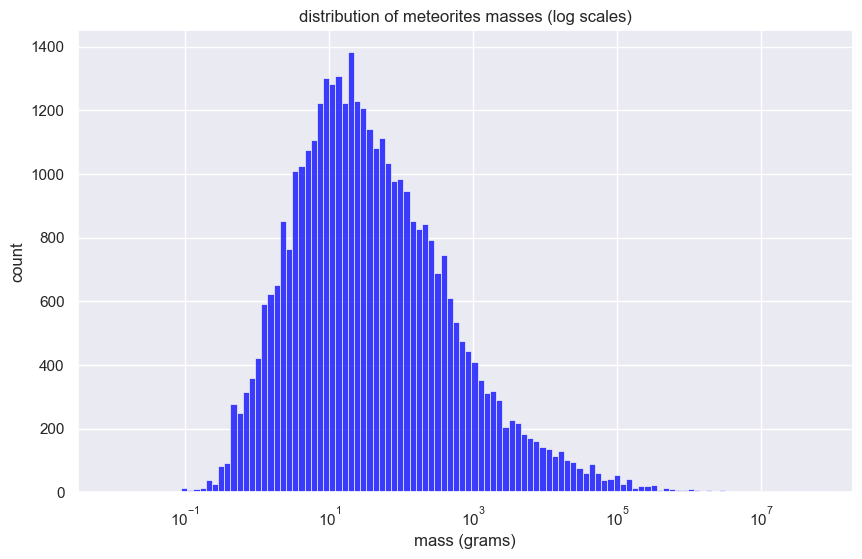

In [10]:
# we can see there are meteorites weights are usually small so we use log_scale=true 

plt.figure(figsize=(10, 6))

sns.histplot(data=columns_cleaned, x='mass', log_scale=True, color='blue')

plt.title('distribution of meteorites masses (log scales)')
plt.xlabel('mass (grams)')
plt.ylabel('count')
plt.show()

## best part is to know that how much frequency of falling meteorites in previous years

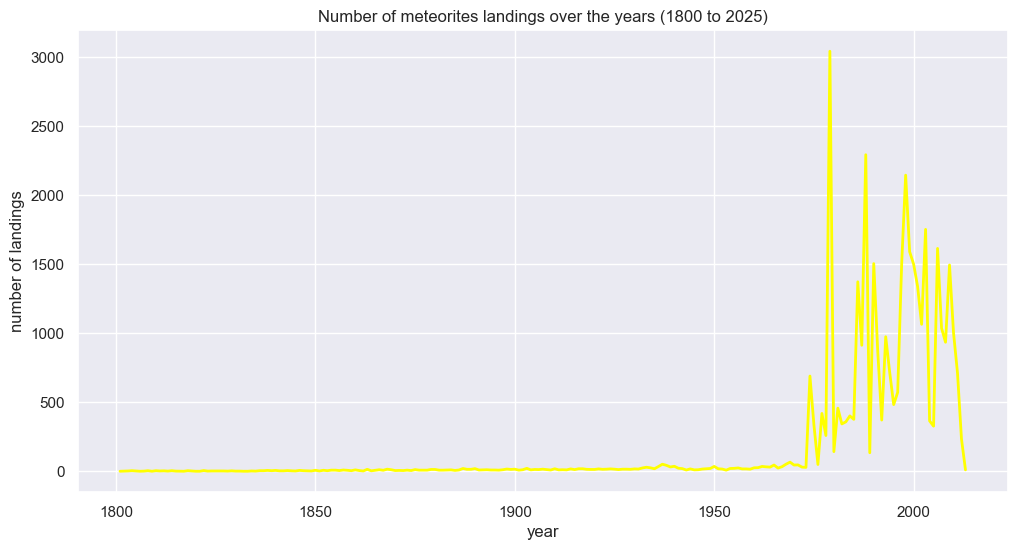

In [20]:
#trends of 150-200 years 

yearly_count = columns_cleaned[(columns_cleaned['year'] >= 1800) & (columns_cleaned['year'] <= 2025)]['year'].value_counts().sort_index()

plt.figure(figsize=(12,6))
sns.lineplot(x=yearly_count.index, y= yearly_count.values, color='yellow', linewidth=2)

plt.title('Number of meteorites landings over the years (1800 to 2025)')
plt.xlabel('year')
plt.ylabel('number of landings')
plt.show()


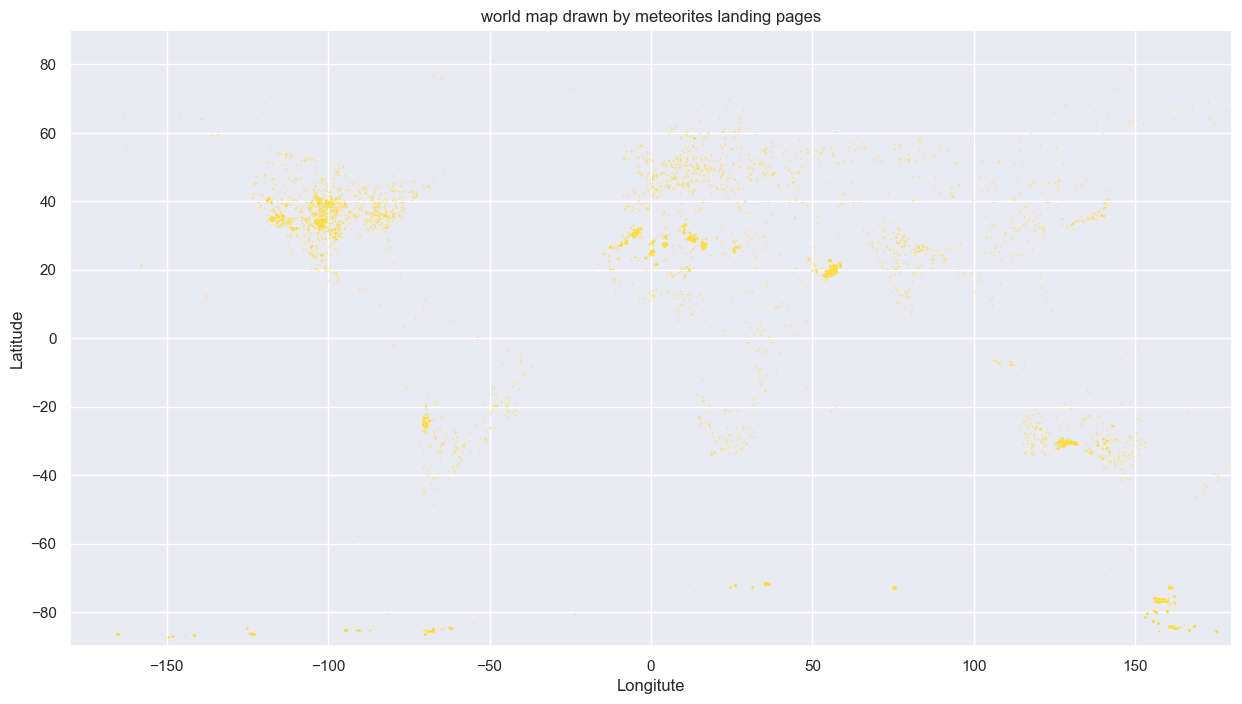

In [27]:
#Drawing the earth map using the cordinates like longitude and langitude

plt.figure(figsize=(15,8))
# Filter out 0 coordinates which might represent missing data mapped to origin


valid_cords = columns_cleaned[(columns_cleaned['reclat'] != 0) & (columns_cleaned['reclong'] != 0)]

sns.scatterplot(data=valid_cords, x='reclong', y='reclat', alpha=0.4, s=2, color='gold')

plt.title('world map drawn by meteorites landing pages')

plt.xlabel('Longitute')
plt.ylabel('Latitude')

plt.xlim(-180, 180)
plt.ylim(-90, 90)
plt.show()